# The following visualizations all compare the values of depression in adults in the given states
# compared with different factors

In [51]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [ ]:
# **The values in the following tables represent the percentage of adults in the state that reported 
# to have been diagnosed with depression or a depressive disorder by a health professional**
# Data Source - CDC, 2023 Behavioral Risk Factor Surveillance System Survey

# DEPRESSION BY INCOME LEVEL (ACROSS STATES) 
- Among adults of varing income levels, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder
- shows the prevalence of depression within each income bracket

In [106]:
# read in csv
df1 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value'])

# make filter for the income labels in the Measure column
incomes = ['Depression - Less Than $25,000','Depression - $25,000-$49,999','Depression - $50,000-$74,999','Depression - $75,000 or More']

# only get entries w/ income in measure
df_clean = df1[df1['Measure'].isin(incomes)] 

# for the visualization later, make a new column w/ desired names for each measure/bin
newNamelyst = [] # make empty list to store new row/entry names when iterating thru measures column

for row in df_clean['Measure']:
    if (row == 'Depression - Less Than $25,000'): # if row == old/original name
          newNamelyst.append('>25k$') # add new name to list for the new column
    elif(row == 'Depression - $25,000-$49,999'):
          newNamelyst.append('25-50k$')
    elif(row == 'Depression - $50,000-$74,999'):
          newNamelyst.append('50-75k$')
    elif(row == 'Depression - $75,000 or More'):
          newNamelyst.append('75k$<')
df_clean['Income Levels'] = newNamelyst # adds the new list of desired labels as new column
df_clean.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_49282/687609235.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Income Levels'] = newNamelyst # adds the new list of desired labels as new column


,Measure,State,Value,Income Levels
85,"Depression - $25,000-$49,999",HI,16.3,25-50k$
86,"Depression - $25,000-$49,999",IA,22.6,25-50k$
87,"Depression - $25,000-$49,999",MI,25.4,25-50k$
88,"Depression - $25,000-$49,999",ND,27.9,25-50k$
89,"Depression - $25,000-$49,999",WV,35.6,25-50k$


In [109]:
# table where states are lines, x axis is income level, and y axis is depression value/percentage

pivot_df = df_clean.pivot(index = 'State', columns=['Income Levels'] , values = 'Value')
# index = state --> make the rows of the table the 'State' column
# columns = measure --> make the column names of the table the income labels 
# values - Value --> make the cell value in the table the depression percentages
    # for each state based on income level 
pivot_df

Income Levels,25-50k$,50-75k$,75k$<,>25k$
State,,,,
HI,16.3,11.8,11.8,25.7
IA,22.6,16.5,14.1,31.3
MI,25.4,21.7,18.5,36.5
ND,27.9,19.4,16.2,39.9
WV,35.6,27.3,22.4,42.9


In [111]:
# Plot the pivot table as a line chart
# - choose order that bins will appear in on the chart
new_column_order = ['>25k$', '25-50k$', '50-75k$', '75k$<'] # make new order
pivot_table_reordered = pivot_df.reindex(columns=new_column_order) # Reorder the columns
# reindex - changes order of columns
# - transpose the pivot table /switch the axes before plotting graph
transposed_pivot = pivot_table_reordered.T # switches axis 
transposed_pivot 

State,HI,IA,MI,ND,WV
Income Levels,,,,,
>25k$,25.7,31.3,36.5,39.9,42.9
25-50k$,16.3,22.6,25.4,27.9,35.6
50-75k$,11.8,16.5,21.7,19.4,27.3
75k$<,11.8,14.1,18.5,16.2,22.4


Text(0, 0.5, 'Depression Score')

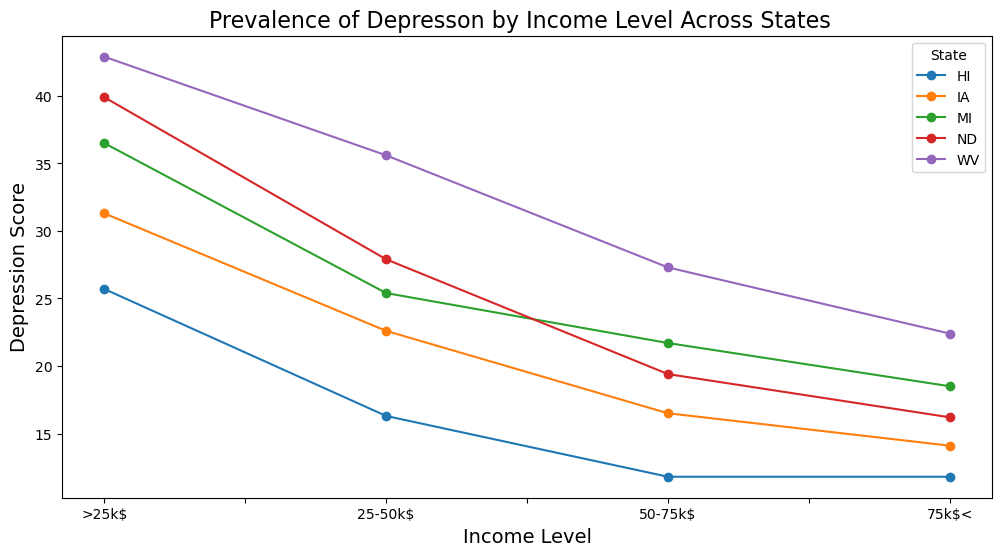

In [112]:
# - use .plot() to make line plot w/ matplotlib
ax = transposed_pivot.plot(kind='line', figsize=(12, 6), marker='o')
    # each column in transposed_pivot dataframe will be a separate line on the plot (states are the lines)
    # mark the data points 
    # assign the plot to "ax" to be able to customize 

#custom_xticklabels = ['>25k$', '25-50k$', '50-75k$', '$75<']
#ax.xticks(labels = custom_xticklabels
ax.set_title("Prevalence of Depresson by Income Level Across States  ",fontsize=16)
ax.set_xlabel("Income Level",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=14)



In [113]:
# Save Figure
DepressionPrevalenceByIncomeFig = ax.get_figure()
DepressionPrevalenceByIncomeFig.savefig("figures/DepressionByIncome_LinePlot.png", bbox_inches = 'tight')

# DEPRESSION BY AGES (ACROSS STATES)
- Among adults of varying ages, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder
- shows the prevalence of depression within each age group

In [115]:
# read in csv
df2 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value'])

# make filter for the income labels in the Measure column
ages = ['Depression - Ages 18-44','Depression - Ages 45-64','Depression - Age 65+']
		
# only get entries w/ age in measure
df_clean2 = df2[df2['Measure'].isin(ages)] 

# for the visualization later, make a new column w/ desired names for each measure/bin
newNamelyst2 = [] # make empty list to store new row/entry names when iterating thru measures column

for row in df_clean2['Measure']:
    if (row == 'Depression - Ages 18-44'): # if row == old/original name
          newNamelyst2.append('18-44 yrs') # add new name to list for the new column
    elif(row == 'Depression - Ages 45-64'):
          newNamelyst2.append('45-65 yrs')
    elif(row == 'Depression - Age 65+'):
          newNamelyst2.append('> 65 yrs')
df_clean2['Age Groups'] = newNamelyst2 # adds the new list of desired labels as new column
df_clean2.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_49282/692679817.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean2['Age Groups'] = newNamelyst2 # adds the new list of desired labels as new column


,Measure,State,Value,Age Groups
15,Depression - Ages 18-44,HI,16.2,18-44 yrs
16,Depression - Ages 18-44,IA,24.0,18-44 yrs
17,Depression - Ages 18-44,MI,29.5,18-44 yrs
18,Depression - Ages 18-44,ND,28.5,18-44 yrs
19,Depression - Ages 18-44,WV,36.5,18-44 yrs


In [117]:
# table where states are lines, x axis is income level, and y axis is depression value/percentage

pivot_df2 = df_clean2.pivot(index = 'State', columns=['Age Groups'] , values = 'Value')
# index = state --> make the rows of the table the 'State' column
# columns = measure --> make the column names of the table the age groups 
# values - Value --> make the cell value in the table the depression percentages
    # for each state based on income level 
pivot_df2

Age Groups,18-44 yrs,45-65 yrs,> 65 yrs
State,,,
HI,16.2,14.0,10.0
IA,24.0,17.9,12.3
MI,29.5,22.7,16.8
ND,28.5,18.5,13.7
WV,36.5,32.8,21.5


In [118]:
# Plot the pivot table as a line chart
# - choose order that bins will appear in on the chart
#new_column_order2 = ['>25k$', '25-50k$', '50-75k$', '75k$<'] # make new order
#pivot_table_reordered = pivot_df.reindex(columns=new_column_order) # Reorder the columns
# reindex - changes order of columns
# - transpose the pivot table /switch the axes before plotting graph
transposed_pivot2 = pivot_df2.T # switches axis 
transposed_pivot2

State,HI,IA,MI,ND,WV
Age Groups,,,,,
18-44 yrs,16.2,24.0,29.5,28.5,36.5
45-65 yrs,14.0,17.9,22.7,18.5,32.8
> 65 yrs,10.0,12.3,16.8,13.7,21.5


Text(0, 0.5, 'Depression Score')

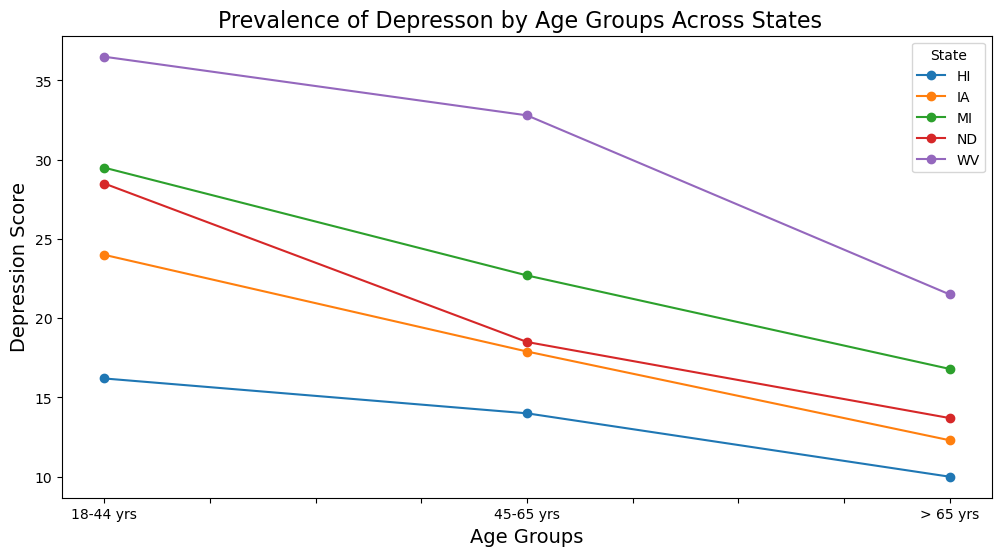

In [119]:
# - use .plot() to make line plot w/ matplotlib
ax = transposed_pivot2.plot(kind='line', figsize=(12, 6), marker='o')
    # each column in transposed_pivot dataframe will be a separate line on the plot (states are the lines)
    # mark the data points 
    # assign the plot to "ax" to be able to customize 

#custom_xticklabels = ['>25k$', '25-50k$', '50-75k$', '$75<']
#ax.xticks(labels = custom_xticklabels
ax.set_title("Prevalence of Depresson by Age Groups Across States  ",fontsize=16)
ax.set_xlabel("Age Groups",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=14)



In [ ]:
# Save Figure
DepressionPrevalenceByAgeGroupFig = ax.get_figure()
DepressionPrevalenceByAgeGroupFig.savefig("figures/DepressionByAgeGroup_LinePlot.png", bbox_inches = 'tight')

# DEPRESSION BY SEX (ACROSS STATES)
- Among males and females, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder 
- shows the prevalence of depression in males vs females

In [120]:
# read in csv
df3 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value'])

# make filter for the income labels in the Measure column
sex = ['Depression - Female','Depression - Male']
	 
# only get entries w/ income in measure
df_clean3 = df3[df3['Measure'].isin(sex)] 

# for the visualization later, make a new column w/ desired names for each measure/bin
newNamelyst3 = [] # make empty list to store new row/entry names when iterating thru measures column

for row in df_clean3['Measure']:
    if (row == 'Depression - Female'): # if row == old/original name
          newNamelyst3.append('Female') # add new name to list for the new column
    elif(row == 'Depression - Male'):
          newNamelyst3.append('Male')
     
df_clean3['Sex'] = newNamelyst3 # adds the new list of desired labels as new column
df_clean3.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_49282/3609221259.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean3['Sex'] = newNamelyst3 # adds the new list of desired labels as new column


,Measure,State,Value,Sex
5,Depression - Female,HI,17.4,Female
6,Depression - Female,IA,25.8,Female
7,Depression - Female,MI,31.2,Female
8,Depression - Female,ND,30.5,Female
9,Depression - Female,WV,39.1,Female


In [125]:
# table where states are lines, x axis is income level, and y axis is depression value/percentage

pivot_df3 = df_clean3.pivot(index = 'State', columns=['Sex'] , values = 'Value')
# index = state --> make the rows of the table the 'State' column
# columns = measure --> make the column names of the table female and male
# values - Value --> make the cell value in the table the depression percentages
    # for each state based on income level 
pivot_df3

Sex,Female,Male
State,,
HI,17.4,10.3
IA,25.8,12.4
MI,31.2,16.7
ND,30.5,14.5
WV,39.1,22.9


In [126]:
# Plot the pivot table as a line chart
# - choose order that bins will appear in on the chart
new_column_order3 = ['Female','Male'] # make new order
pivot_table_reordered3 = pivot_df3.reindex(columns=new_column_order3) # Reorder the columns
# reindex - changes order of columns
# - transpose the pivot table /switch the axes before plotting graph
transposed_pivot3 = pivot_table_reordered3.T # switches axis 
transposed_pivot3

State,HI,IA,MI,ND,WV
Sex,,,,,
Female,17.4,25.8,31.2,30.5,39.1
Male,10.3,12.4,16.7,14.5,22.9


In [ ]:
# grouped bar plot

AttributeError: 'Axes' object has no attribute 'set_xtickslabels'

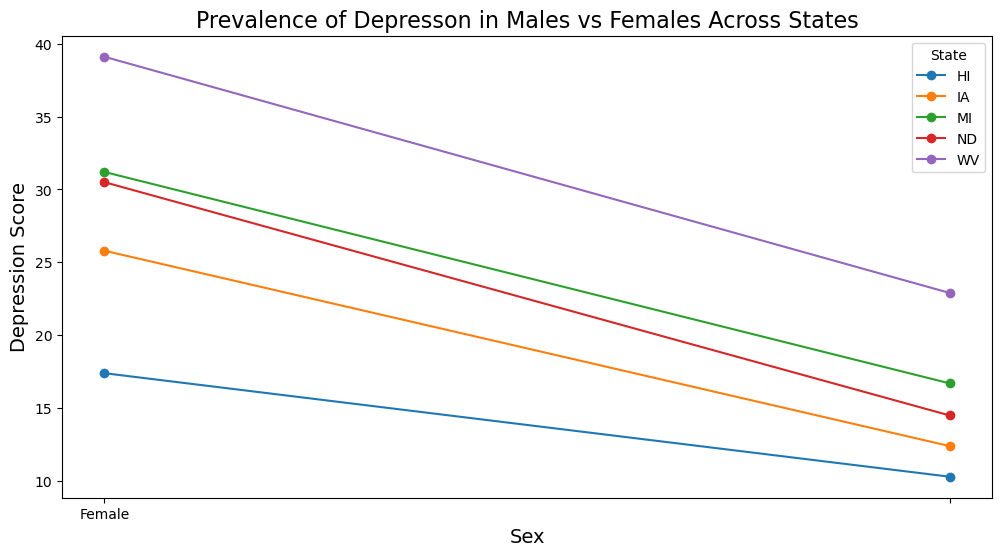

In [131]:
# - use .plot() to make line plot w/ matplotlib
ax = transposed_pivot3.plot(kind='line', figsize=(12, 6), marker='o')
    # each column in transposed_pivot dataframe will be a separate line on the plot (states are the lines)
    # mark the data points 
    # assign the plot to "ax" to be able to customize 

#custom_xticklabels = ['>25k$', '25-50k$', '50-75k$', '$75<']
#ax.xticks(labels = custom_xticklabels
ax.set_title("Prevalence of Depresson in Males vs Females Across States",fontsize=16)
ax.set_xlabel("Sex",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=14)
ax.set_xticks([0, 1])
ax.set_xtickslabels(['Female','Male'])

# DEPRESSION IN METRO VS NON METRO AREAS (ACROSS STATES)

# DEPRESSION IN METRO VS NON METRO AREAS (ACROSS STATES)

# DEPRESSION ACROSS POPULATIONS WITH VARIOUS DIFFICULTIES (ACROSS STATES)

# DEPRESSION BY SERVED VS NON SERVED (ACROSS STATES)